<a href="https://colab.research.google.com/github/vighneshkhot10/CSL701-ce24_Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vighnesh Dkhot

  BECE-19                        
    Exp-06

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


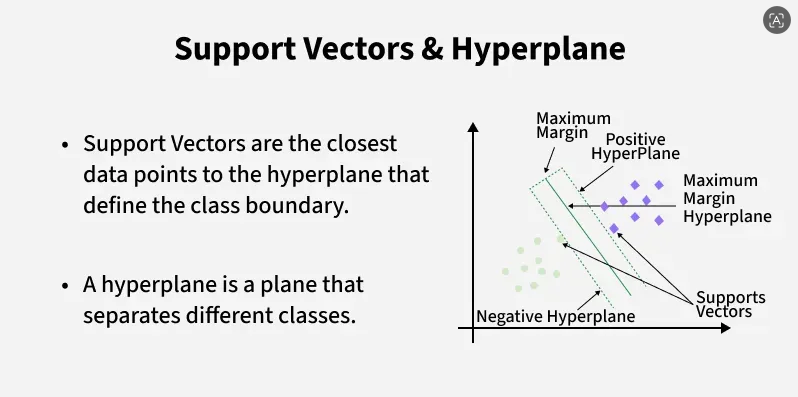
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

print("Iris dataset loaded successfully.")


Iris dataset loaded successfully.


# Task 2: Explore the Dataset

In [ ]:
# Display first 10 rows
print("\nFirst 10 rows of the dataset:")
display(df.head(10))

# Display last 5 rows
print("\nLast 5 rows of the dataset:")
display(df.tail(5))

# Check dataset dimensions
print(f"\nDataset dimensions: {df.shape}")

# Display dataset information
print("\nDataset information:")
df.info()

# Generate summary statistics
print("\nSummary statistics:")
display(df.describe())

# Record mean, minimum and maximum values of Age and Fare (Iris dataset does not have 'Age' or 'Fare')
# Assuming 'sepal length (cm)' and 'petal width (cm)' as representative features
print(f"\nMean of Sepal Length: {df['sepal length (cm)'].mean():.2f}")
print(f"Minimum of Sepal Length: {df['sepal length (cm)'].min():.2f}")
print(f"Maximum of Sepal Length: {df['sepal length (cm)'].max():.2f}")

print(f"\nMean of Petal Width: {df['petal width (cm)'].mean():.2f}")
print(f"Minimum of Petal Width: {df['petal width (cm)'].min():.2f}")
print(f"Maximum of Petal Width: {df['petal width (cm)'].max():.2f}")

# Identify missing values
print("\nMissing values:")
print(df.isnull().sum())



First 10 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0



Last 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2



Dataset dimensions: (150, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Summary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Mean of Sepal Length: 5.84
Minimum of Sepal Length: 4.30
Maximum of Sepal Length: 7.90

Mean of Petal Width: 1.20
Minimum of Petal Width: 0.10
Maximum of Petal Width: 2.50

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Task 9: Fill missing Age values with the median. (Not applicable to Iris dataset as there are no missing values in numeric columns, and no 'Age' column).
# If there were missing values, the code would look like: df['Age'].fillna(df['Age'].median(), inplace=True)

# Task 10: Filter surviving passengers (Survived == 1). (Not applicable to Iris dataset)
# If applicable, the code would look like: df_survived = df[df['Survived'] == 1]

# Task 11: Convert Fare column to a NumPy array. (Not applicable to Iris dataset)
# If applicable, the code would look like: fare_array = df['Fare'].to_numpy()

# Task 12: Calculate maximum and average Fare using np.max() and np.mean(). (Not applicable to Iris dataset)
# If applicable, the code would look like: max_fare = np.max(fare_array); avg_fare = np.mean(fare_array)


print("Iris dataset has no missing values and does not contain 'Age' or 'Fare' columns as described in the original prompt.")
print("Proceeding to define features (X) and target (y) for classification.")

# Define features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Iris dataset has no missing values and does not contain 'Age' or 'Fare' columns as described in the original prompt.
Proceeding to define features (X) and target (y) for classification.

Features (X) shape: (150, 4)
Target (y) shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled successfully.")


Training features shape: (120, 4)
Testing features shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)

Data scaled successfully.


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# Initialize LinearSVC model
svm_model = LinearSVC(random_state=42, max_iter=5000)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM model trained and predictions made.")


Linear SVM model trained and predictions made.


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Model Accuracy: 1.0000

Confusion Matrix for SVM:


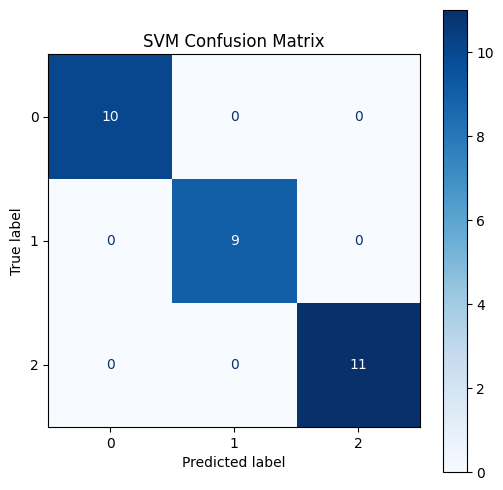


Classification Report for SVM:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

# Generate and display confusion matrix
print("\nConfusion Matrix for SVM:")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_scaled, y_test, cmap=plt.cm.Blues, ax=ax)
plt.title("SVM Confusion Matrix")
plt.show()

# Generate and print classification report
print("\nClassification Report for SVM:")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))


# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

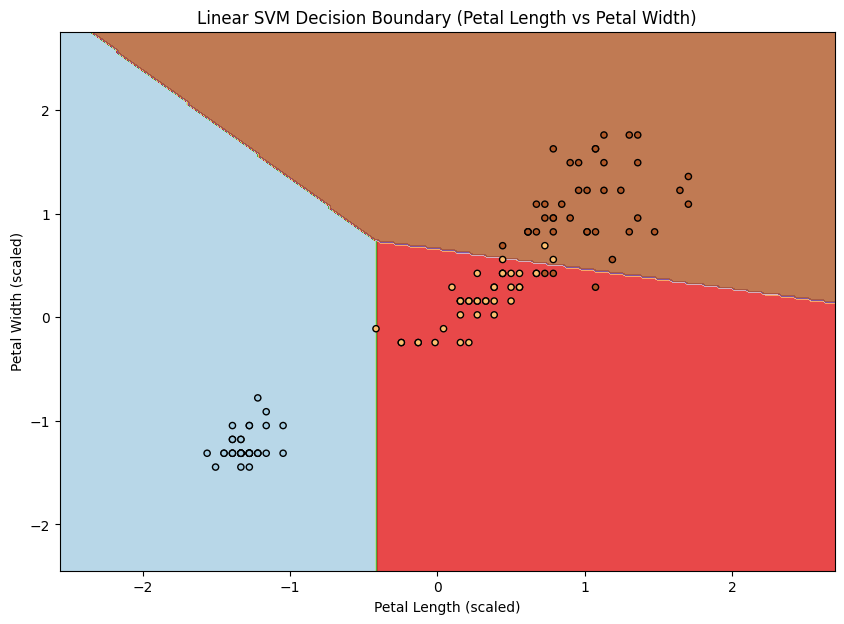

In [ ]:
# Select Petal Length and Petal Width for 2D visualization
df_2d = df[['petal length (cm)', 'petal width (cm)', 'species']]
X_2d = df_2d[['petal length (cm)', 'petal width (cm)']]
y_2d = df_2d['species']

# Split 2D data
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Scale 2D data
scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

# Train Linear SVM on 2D data
svm_2d_model = LinearSVC(random_state=42, max_iter=5000)
svm_2d_model.fit(X_2d_train_scaled, y_2d_train)

# Plot Decision Boundary
# Create a meshgrid to plot decision boundary
x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_2d_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1], c=y_2d_train, cmap=plt.cm.Paired, edgecolors='k', s=20)
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('Linear SVM Decision Boundary (Petal Length vs Petal Width)')
plt.show()


# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

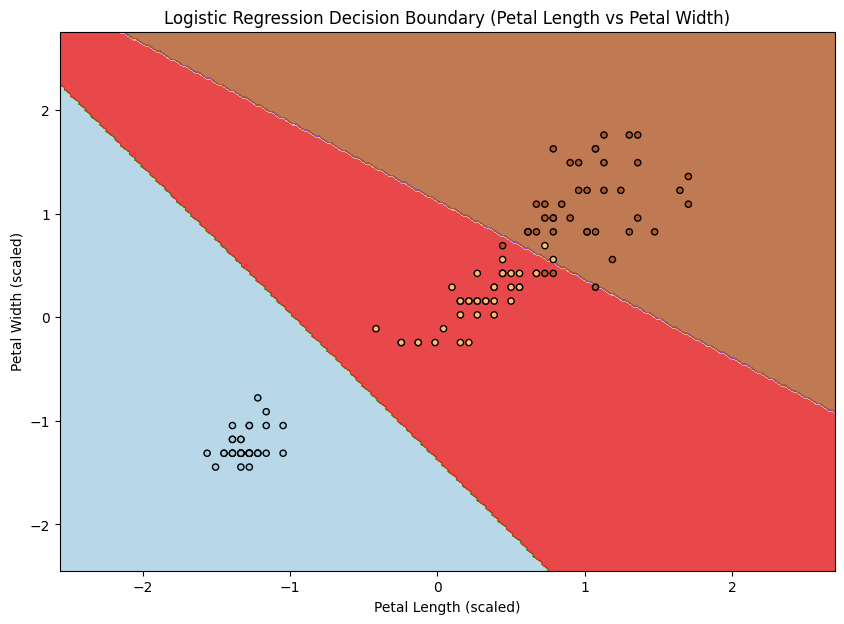

In [ ]:
# Initialize Logistic Regression model
logreg_2d_model = LogisticRegression(random_state=42, max_iter=5000)

# Train the Logistic Regression model on 2D data
logreg_2d_model.fit(X_2d_train_scaled, y_2d_train)

# Predict on the meshgrid for decision boundary
Z_logreg = logreg_2d_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_logreg = Z_logreg.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_logreg, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1], c=y_2d_train, cmap=plt.cm.Paired, edgecolors='k', s=20)
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('Logistic Regression Decision Boundary (Petal Length vs Petal Width)')
plt.show()


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

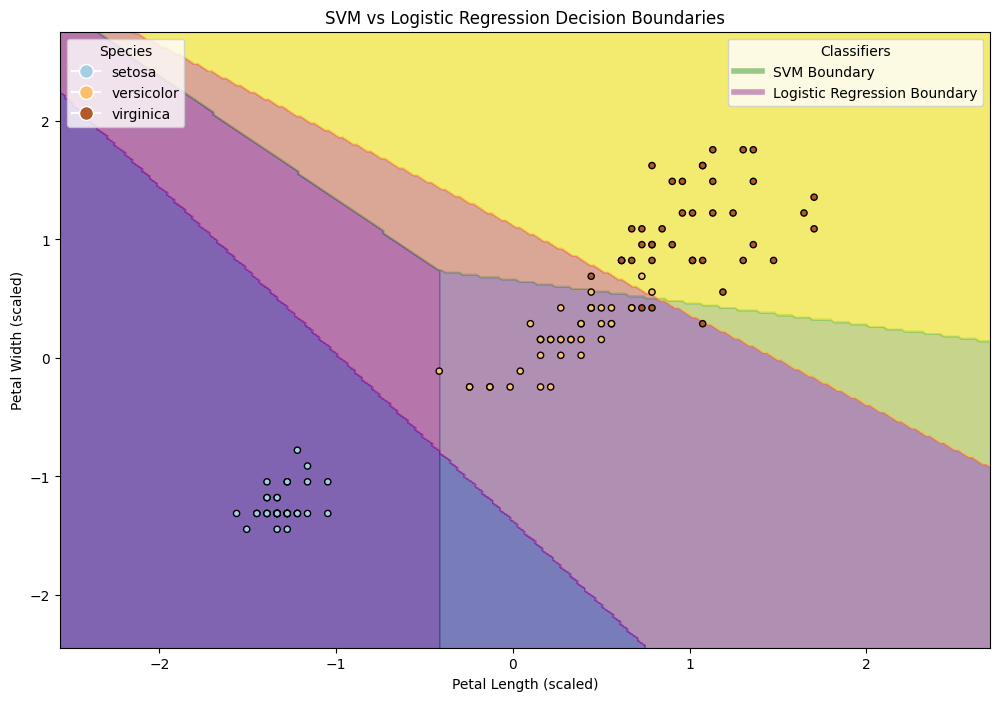

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot SVM decision boundary
ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis, linestyles='--')

# Plot Logistic Regression decision boundary
ax.contourf(xx, yy, Z_logreg, alpha=0.4, cmap=plt.cm.plasma, linestyles=':')

# Plot data points
scatter = ax.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1], c=y_2d_train, cmap=plt.cm.Paired, edgecolors='k', s=20)

ax.set_xlabel('Petal Length (scaled)')
ax.set_ylabel('Petal Width (scaled)')
ax.set_title('SVM vs Logistic Regression Decision Boundaries')

# Create custom legend for decision boundaries
from matplotlib.lines import Line2D
legend_elements_boundary = [
    Line2D([0], [0], color='green', lw=4, label='SVM Boundary', alpha=0.4),
    Line2D([0], [0], color='purple', lw=4, label='Logistic Regression Boundary', alpha=0.4)
]

# Create proxy artists for the scatter points for the species legend
colors = plt.cm.Paired(np.linspace(0, 1, len(iris.target_names))) # Get colors from the colormap
species_legend_handles = []
for i, name in enumerate(iris.target_names):
    species_legend_handles.append(Line2D([0], [0], marker='o', color='w', label=name,
                                         markerfacecolor=colors[i], markersize=10))

# Create legend for data points (species)
legend_species = ax.legend(handles=species_legend_handles, title="Species", loc="upper left")

# Add the species legend to the axes
ax.add_artist(legend_species)

# Create the second legend for the decision boundaries
legend_classifiers = ax.legend(handles=legend_elements_boundary, loc='upper right', title='Classifiers')

plt.show()


# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---


--- Comparing Performance on Full Dataset ---

Linear SVM Performance:
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Logistic Regression Performance:
Accuracy: 1.0000

Confusion Matrix for Logistic Regression:


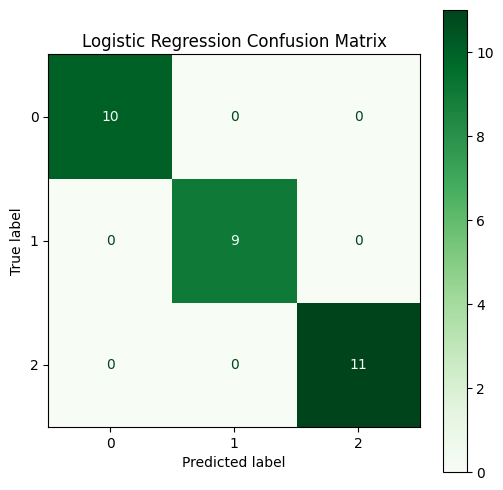


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Performance Summary ---
Linear SVM Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000
Both models achieved similar accuracy.


In [ ]:
print("\n--- Comparing Performance on Full Dataset ---\n")

# Performance of Linear SVM (already calculated in Task 6)
print("Linear SVM Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=iris.target_names))

# Initialize Logistic Regression model for full dataset
logreg_model = LogisticRegression(random_state=42, max_iter=5000)

# Train Logistic Regression model
logreg_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logreg = logreg_model.predict(X_test_scaled)

# Calculate accuracy for Logistic Regression
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_logreg:.4f}")

# Generate and display confusion matrix for Logistic Regression
print("\nConfusion Matrix for Logistic Regression:")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_scaled, y_test, cmap=plt.cm.Greens, ax=ax)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Generate and print classification report for Logistic Regression
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_logreg, target_names=iris.target_names))

print("\n--- Performance Summary ---")
print(f"Linear SVM Accuracy: {accuracy_svm:.4f}")
print(f"Logistic Regression Accuracy: {accuracy_logreg:.4f}")

if accuracy_svm > accuracy_logreg:
    print("Linear SVM performed slightly better in terms of accuracy.")
elif accuracy_logreg > accuracy_svm:
    print("Logistic Regression performed slightly better in terms of accuracy.")
else:
    print("Both models achieved similar accuracy.")


# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.